<a href="https://colab.research.google.com/github/dz-web3/DS-Tech-2026spring/blob/main/Module6_Text_NaiveBayes/mining_text.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#If opening in colab run this cell

!git clone https://github.com/dz-web3/DS-Tech-2026spring.git
%cd DS-Tech-2026spring/Module6_Text_NaiveBayes

Cloning into 'DS-Tech-2026spring'...
remote: Enumerating objects: 249, done.
remote: Counting objects: 100% (151/151), done.
remote: Compressing objects: 100% (124/124), done.
remote: Total 249 (delta 63), reused 86 (delta 25), pack-reused 98 (from 1)
Receiving objects: 100% (249/249), 15.54 MiB | 8.65 MiB/s, done.
Resolving deltas: 100% (88/88), done.
Updating files: 100% (45/45), done.
/content/DS-Tech-2026spring/Module6_Text_NaiveBayes


# Dealing with text (and another ML algorithm: Naive Bayes)


Spring 2026 - Instructor: Foster Provost and Baotong Zhang

Teaching Assistant: Baotong Zhang
***

In [2]:
# Import the libraries we will be using
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn import metrics
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer

import matplotlib.pylab as plt
%matplotlib inline

# We will want to keep track of some different roc curves, lets do that here
tprs = []
fprs = []
roc_labels = []
aucs = []

## Document classification and customer satisfaction

Our problem setting: You've been hired by Trans American Airlines (TAA) as a business analytics professional. One of the top priorities of TAA is  customer service. For TAA, it is of utmost importance to identify whenever customers are unhappy with the way employees have treated them. You've been hired to analyze twitter data in order to detect whenever a customer has complaints about flight attendants. Tweets suspected to be related to flight attendant complaints should be forwarded directly to the customer service department in order to track the issue and take corrective actions.  

Let's start by loading the data.

In [3]:
data_path = 'data/tweets.csv'
df = pd.read_csv(data_path)
df.head()

,tweet_id,airline_sentiment,airline_sentiment_confidence,negativereason,negativereason_confidence,name,retweet_count,text,tweet_created,user_timezone
0,5.703060e+17,neutral,1.0000,NaN,NaN,cairdin,0,@TAA What @dhepburn said.,2/24/2015 11:35,Eastern Time (US & Canada)
1,5.703010e+17,positive,0.3486,NaN,0.0000,jnardino,0,@TAA plus you've added commercials to the expe...,2/24/2015 11:15,Pacific Time (US & Canada)
2,5.703010e+17,neutral,0.6837,NaN,NaN,yvonnalynn,0,@TAA I didn't today... Must mean I need to tak...,2/24/2015 11:15,Central Time (US & Canada)
3,5.703010e+17,negative,1.0000,Bad Flight,0.7033,jnardino,0,@TAA it's really aggressive to blast obnoxious...,2/24/2015 11:15,Pacific Time (US & Canada)
4,5.703010e+17,negative,1.0000,Can't Tell,1.0000,jnardino,0,@TAA and it's a really big bad thing about it,2/24/2015 11:14,Pacific Time (US & Canada)


Let's take a look at what do people complain about in Twitter.

In [4]:
df.shape


(14640, 10)

In [5]:
df.negativereason.value_counts()

,count
negativereason,
Customer Service Issue,2910
Late Flight,1665
Can't Tell,1190
Cancelled Flight,847
Lost Luggage,724
Bad Flight,580
Flight Booking Problems,529
Flight Attendant Complaints,481
longlines,178


We will define our target variable based on "Flight Attendant Complaints"

In [6]:
# We'll call our target variable "is_fa_complaint" and keep only the text as a "feature" (really, the text is the field from which we will engineer features)
df["is_fa_complaint"] = (df.negativereason == "Flight Attendant Complaints").astype(int)
df = df[["is_fa_complaint", "text"]]
df.shape

(14640, 2)

Let's take a look at the percentage of tweets related to complaints about flight attendants, aka the base rate:

In [7]:
df['is_fa_complaint'].mean()

np.float64(0.032855191256830604)

Here are some examples of the tweets.

In [8]:
print("Flagged as FA complaints:")
print(df[df.is_fa_complaint == 1].text.values[0:5])

print("\nNot flagged as FA complaint:")
print(df[df.is_fa_complaint == 0].text.values[0:5])

Flagged as FA complaints:
['@TAA your airline is awesome but your lax loft needs to step up its game. $40 for dirty tables and floors? http://t.co/hy0VrfhjHt'
 "@TAA You'd think paying an extra $100 bucks RT for luggage might afford you hiring an extra hand at @sfo #lame"
 '@TAA  for all my flight stuff wrong and did nothing about it. Had #worst #flight ever'
 '@TAA husband and I ordered three drinks via my screen and they never came. Awesome!'
 '@TAA All of group E was told there was no more room in the bins. when I got on the plane, was room for at least 4 bags in my row!']

Not flagged as FA complaint:
['@TAA What @dhepburn said.'
 "@TAA plus you've added commercials to the experience... tacky."
 "@TAA I didn't today... Must mean I need to take another trip!"
 '@TAA it\'s really aggressive to blast obnoxious "entertainment" in your guests\' faces &amp; they have little recourse'
 "@TAA and it's a really big bad thing about it"]


Since we are going to do some predictive modeling, we should split our data into a training and a test set.

In [9]:
X = df['text']
Y = df['is_fa_complaint']

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=.2, random_state=42)

### Text to features
How can we turn the large amount of text for each record into useful features?


#### Binary representation
One way is to create a matrix that uses each word as a feature and keeps track of whether or not a word appears in a document/record. You can do this in sklearn with a `CountVectorizer()` and setting `binary` to `true`. The process is very similar to how you fit a model: you will fit a `CounterVectorizer()`. This will figure out what words exist in your data.

In [10]:
binary_vectorizer = CountVectorizer(binary=True)
binary_vectorizer.fit(X_train)

CountVectorizer(binary=True)

Let's look at the vocabulary the `CountVectorizer()` learned.

In [11]:
vocabulary_list = list(zip( binary_vectorizer.vocabulary_.keys(), binary_vectorizer.vocabulary_.values()) )

vocabulary_list[0:10]

[('taa', 11423),
 ('you', 13183),
 ('are', 2113),
 ('offering', 8578),
 ('us', 12427),
 ('rooms', 10179),
 ('for', 5391),
 ('32', 674),
 ('people', 8994),
 ('fail', 5021)]

Now that we know what words are in the data, we can transform our text into a clean matrix. Simply .transform() the raw data using our fitted CountVectorizer(). You will do this for the training and test data. What do you think happens if there are new words in the test data that were not seen in the training data?

In [12]:
X_train_binary = binary_vectorizer.transform(X_train)
X_test_binary = binary_vectorizer.transform(X_test)

In [13]:
X_train_binary.shape

(11712, 13271)

In [14]:
X_test_binary.shape

(2928, 13271)

We can take a look at our new `X_test_binary`.

In [15]:
X_test_binary

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 45588 stored elements and shape (2928, 13271)>

Sparse matrix? Where is our data?

If you look at the output above, you will see that it is being stored in a *sparse* matrix (as opposed to the typical dense matrix) that is 3k rows long and 13k columns. The rows here are records in the original data and the columns are words. Given the shape, this means there are 39m cells that should have values. However, from the above, we can see that only 46k cells (~0.12%) of the cells have values! Why is this?

To save space, sklearn uses a sparse matrix. This means that only values that are not zero are stored. This saves a ton of space! This also means that visualizing the data is a little trickier. Let's look at a very small chunk.

In [16]:
# Recall that 13183 is the index for "you"
X_test_binary[0:20, 13180:13200].todense()

matrix([[0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0,

#### Applying a model
Now that we have a ton of features (one for every word!) let's try using a logistic regression model to predict which tweets are about flight attendant complaints.

AUC for binary = 0.834


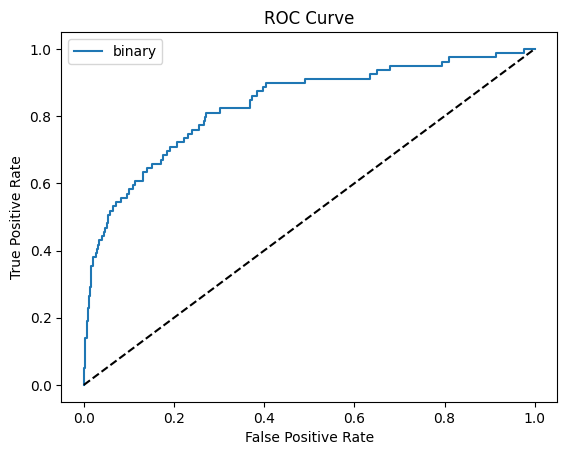

In [17]:
def get_model_roc(models, Xs_test, names, Y_test):
    plt.rcParams['figure.dpi'] = 100
    for i in range(len(models)):
        model = models[i]
        X_test = Xs_test[i]
        name = names[i]
        probs = model.predict_proba(X_test)[:,1]
        fpr, tpr, thresholds = metrics.roc_curve(Y_test, probs)
        plt.plot(fpr, tpr, label=name)
        plt.plot([0, 1], [0, 1], linestyle='dashed', color='black')
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.title("ROC Curve")
        print ("AUC for {0} = {1:.3f}".format(name, metrics.roc_auc_score(Y_test, probs)))
    plt.legend()
    plt.show()


model_binary = LogisticRegression(solver='liblinear')
model_binary.fit(X_train_binary, Y_train)
get_model_roc([model_binary], [X_test_binary], ['binary'], Y_test)
#Note that if you were doing this for real, you'd want to make sure you are regularizing well!

#### Counts instead of binary
Instead of using a 0 or 1 to represent the occurence of a word, we can use the actual counts. We do this the same way as before, but now we leave `binary` set to `false` (the default value).

AUC for binary = 0.834
AUC for counts = 0.831


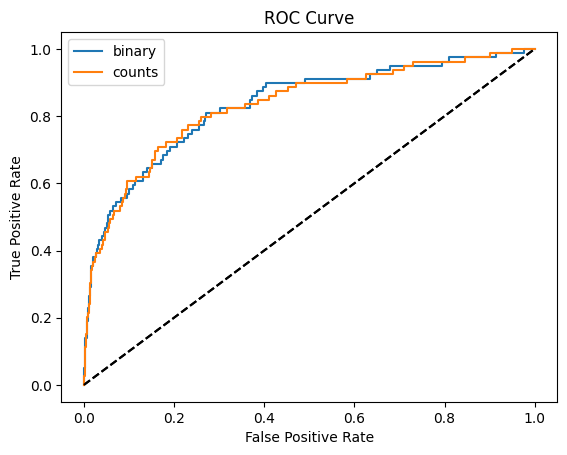

In [18]:
# Fit a counter
count_vectorizer = CountVectorizer()
count_vectorizer.fit(X_train)

# Transform to counts
X_train_counts = count_vectorizer.transform(X_train)
X_test_counts = count_vectorizer.transform(X_test)

# Model
model_counts = LogisticRegression(solver='liblinear')
model_counts.fit(X_train_counts, Y_train)

get_model_roc([model_binary, model_counts], [X_test_binary, X_test_counts], ['binary', 'counts'], Y_test)

#### Tf-idf
Another popular technique when dealing with text is to use the term frequency - inverse document frequency (tf-idf) measure instead of just counts as the feature values (see the book).

AUC for binary = 0.834
AUC for tf-idf = 0.856


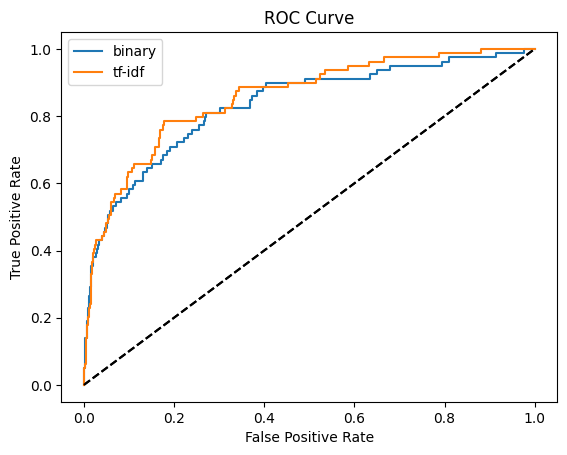

In [19]:
# Fit vectorizer
tfidf_vectorizer = TfidfVectorizer()
tfidf_vectorizer.fit(X_train)

# Transform to tfidf
X_train_tfidf = tfidf_vectorizer.transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

# Model
model_tfidf = LogisticRegression(solver='liblinear')
model_tfidf.fit(X_train_tfidf, Y_train)

get_model_roc([model_binary, model_tfidf], [X_test_binary, X_test_tfidf], ['binary', 'tf-idf'], Y_test)

The `CountVectorizer()` and `TfidfVectorizer()` functions have many options. You can restrict the words you would like in the vocabulary. You can add n-grams. You can use stop word lists. Which options you should use generally depends on the specific data you are dealing with.

AUC for binary = 0.834
AUC for 2-ngram = 0.863


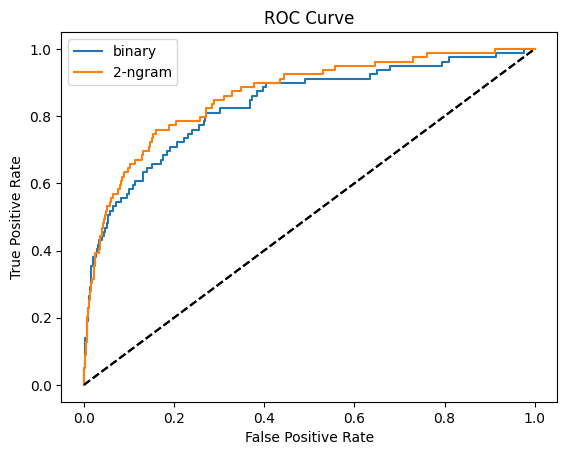

In [20]:
# Try stop words and ngrams up to n=2
ngram_vectorizer = TfidfVectorizer(stop_words='english', ngram_range=(1, 2))
ngram_vectorizer.fit(X_train)

# Transform with the vectorizer
X_train_ngram = ngram_vectorizer.transform(X_train)
X_test_ngram = ngram_vectorizer.transform(X_test)

# Fit the model
model_ngram = LogisticRegression(solver='liblinear')
model_ngram.fit(X_train_ngram, Y_train)

get_model_roc([model_binary, model_ngram], [X_test_binary, X_test_ngram], ['binary', '2-ngram'], Y_test)

### Modeling with another technique: Naive Bayes

So far we have been exposed to tree-structured models and logistic regression in class, as well as non-linear methods based on these (like RandomForests and LR with polynomial features). Now, it's time for another popular modeling technique for supervised learning (especially in text classification): Naive Bayes (NB). In particular, we are using a Bernoulli Naive Bayes (BNB) for our binary classification task. (Bernoulli NB is the model described in the book; there are other versions of NB -- see below.)

As described in your text, the Naive Bayes model is a **probabilistic approach which assumes conditional independence between features** (in this case, each word/ngram is a feature, the conditioning is on the true class). In other words, Naive Bayes models the probabilities of the presence of each _word_, given that we have a flight attendant complaint, and given that we do not have a flight attendant complaint.  Then it combines them using Bayes Theorem (again, as described in the book) to give an estimated probability of the class to an instance.

Using this model in sklearn works just the same as the others we've seen ([More details here..](http://scikit-learn.org/stable/modules/naive_bayes.html))

- Choose the model
- Fit the model (Train)
- Predict with the model (Train or Test or Use data)

In [21]:
from sklearn.naive_bayes import BernoulliNB

model_nb = BernoulliNB()
model_nb.fit(X_train_binary, Y_train)

BernoulliNB()

AUC for binary = 0.834
AUC for naive-bayes = 0.802


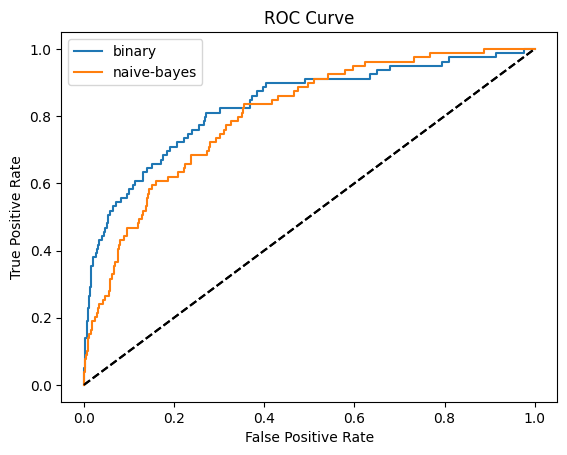

In [22]:
get_model_roc([model_binary, model_nb], [X_test_binary, X_test_binary], ['binary', 'naive-bayes'], Y_test)

The past few weeks we have seen that many of the models we are using have different complexity control hyperparameters that can be tweaked. In naive Bayes, the hyperparameter that is typically tuned is the Laplace smoothing value **`alpha`**.  You can try to see whether tuning alpha helps improve on the results above.

Also, there are other versions of naive Bayes:

1. **Multinomial naive Bayes (MNB):** This model handles count features and not just binary features. Sometimes MNB is used with binary presence/absence variables anyway (like word presence), even though that violates the model assumptions, because in practice it still works well.
2. **Gaussian Naive Bayes (GNB):** This model considers likelihood of the features as Gaussian--and thus we can use it for continuous features.  Sometimes GNB and Bernoulli NB are combined when one has features of mixed types.  

You can try out all of these alternatives!


## Exploring Word Embeddings

In all of the text processing above, we used **bag-of-words** representations (CountVectorizer, TF-IDF). Each word is treated as an independent feature — the model has no idea that "good" and "great" are related, or that "apple" can mean both a fruit and a tech company.

**Word embeddings** are a different approach: each word is represented as a dense vector of (say) 100 numbers, learned from huge amounts of text. Words that appear in similar contexts end up with similar vectors. Let's explore what these vectors look like and what their dimensions capture.

In [23]:
!pip install gensim -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 38.3 MB/s eta 0:00:00


In [24]:
import gensim.downloader as api
glove = api.load('glove-wiki-gigaword-100')
print(f"Vocabulary size: {len(glove):,} words")
print(f"Embedding dimensions: {glove.vectors.shape[1]}")

[==================================================] 100.0% 128.1/128.1MB downloaded
Vocabulary size: 400,000 words
Embedding dimensions: 100


### What does an embedding look like?

Let's look at the embedding vector for the word **"apple"** — a word with multiple meanings (fruit *and* tech company). Each of its 100 dimensions is just a number, but together they encode the word's meaning.

In [25]:
apple_vector = glove['apple']
print(f"Shape: {apple_vector.shape}")
print(f"\nFirst 10 values: {apple_vector[:10].round(3)}")

Shape: (100,)

First 10 values: [-0.598 -0.463  0.13  -0.02   0.46  -0.302  0.898 -0.656  0.669 -0.492]


### What do the dimensions mean?

Each dimension is just a number — but can we figure out what concept it captures? Here's our approach:

1. **Find apple's top-K dimensions** — the dimensions where apple scores highest
2. **For each dimension, find which words score highest** across the entire vocabulary
3. **Look for patterns** — do some dimensions look "fruity" and others "techy"?

In [26]:
K = 10
top_dims = np.argsort(apple_vector)[::-1][:K]

for i, dim in enumerate(top_dims):
    print(f"#{i+1}: Dimension {dim} (value = {apple_vector[dim]:.3f})")

#1: Dimension 31 (value = 1.611)
#2: Dimension 71 (value = 1.430)
#3: Dimension 98 (value = 1.343)
#4: Dimension 58 (value = 1.141)
#5: Dimension 38 (value = 0.981)
#6: Dimension 35 (value = 0.961)
#7: Dimension 80 (value = 0.926)
#8: Dimension 19 (value = 0.921)
#9: Dimension 25 (value = 0.912)
#10: Dimension 6 (value = 0.898)


In [27]:
words = glove.index_to_key  # full vocabulary in order

for i, dim in enumerate(top_dims):
    # Get scores for this dimension across all words
    scores = glove.vectors[:, dim]
    top_word_indices = np.argsort(scores)[::-1][:10]
    print(f"--- Dimension {dim} (apple value = {apple_vector[dim]:.3f}) ---")
    for idx in top_word_indices:
        print(f"  {words[idx]:20s} {scores[idx]:.3f}")
    print()

--- Dimension 31 (apple value = 1.611) ---
  āb                   2.667
  īn                   2.376
  soflá                2.291
  bāgh-e               2.222
  eh-ye                2.187
  gamerankings         2.181
  401                  2.129
  comcast              2.092
  bīd                  2.087
  jgr                  2.061

--- Dimension 71 (apple value = 1.430) ---
  ibes                 2.636
  (727)                2.480
  gamerankings         2.461
  9a-4p                2.411
  (813)                2.263
  economy.com          2.259
  decadal              2.230
  allmusic             2.216
  apoyo                2.216
  6-pica               2.192

--- Dimension 98 (apple value = 1.343) ---
  v8                   2.388
  motor                2.347
  auto                 2.249
  rodong               2.238
  seating              2.210
  sinmun               2.189
  interscholastic      2.167
  sports               2.092
  luxury               2.083
  expander             2.076

### What do you see?

Look at the word lists above. For each dimension, ask yourself:
- **Is there a theme?** Do the top words seem related to fruit/food, or to technology/companies, or something else?
- **Can you give the dimension a name?** (e.g., "fruit-ness", "tech-company-ness")

Not every dimension will have a clean human-interpretable theme — and that's okay. The point is that the embedding captures *multiple aspects* of a word's meaning across different dimensions.

In [28]:
summary = {}
for dim in top_dims:
    scores = glove.vectors[:, dim]
    top_indices = np.argsort(scores)[::-1][:10]
    summary[f"Dim {dim}"] = [words[idx] for idx in top_indices]

pd.DataFrame(summary)

,Dim 31,Dim 71,Dim 98,Dim 58,Dim 38,Dim 35,Dim 80,Dim 19,Dim 25,Dim 6
0,āb,ibes,v8,service,govpx,gandolfo,kahr,qal,garlic,g6
1,īn,(727),motor,airlines,n.y.,distillate,madoff,elfman,lasith,undervotes
2,soflá,gamerankings,auto,air,dispatcher,muoi,thousands,kx,sreesanth,glafcos
3,bāgh-e,9a-4p,rodong,flights,navajo,subfamily,tens,actress,liezel,agusta
4,eh-ye,(813),seating,cargo,uncial,monotypic,billions,multi-engine,9a-4p,lancer
5,gamerankings,economy.com,sinmun,-,resend,nondurable,hundreds,incertae,eniwetok,yearling
6,401,decadal,interscholastic,its,louima,hotton,janjaweed,christgau,breathnach,spaniel
7,comcast,allmusic,sports,airline,ghneim,siderurgica,samsung,widowers,beaks,byes
8,bīd,apoyo,luxury,airspace,limpets,makuuchi,fraud,aggregator,pelzer,kazhagam
9,jgr,6-pica,expander,stock,discal,500-stock,evasion,actor,malinga,hemings


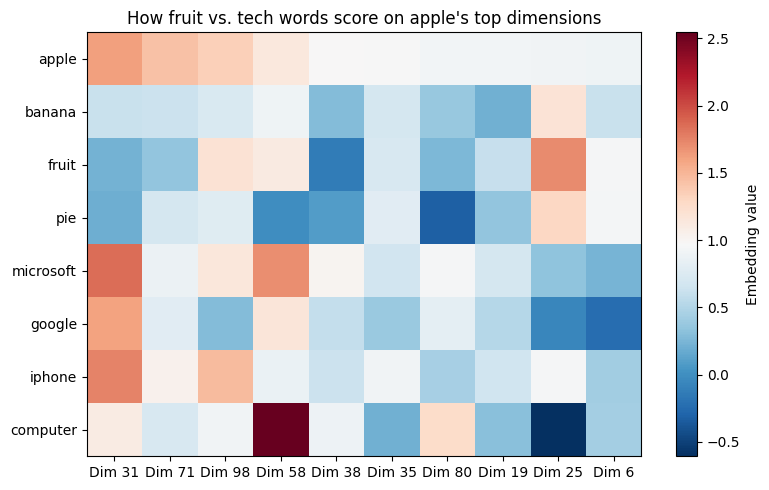

In [29]:
comparison_words = ['apple', 'banana', 'fruit', 'pie',
                    'microsoft', 'google', 'iphone', 'computer']

# Build matrix: rows = words, columns = top dims
matrix = np.array([glove[w][top_dims] for w in comparison_words])

fig, ax = plt.subplots(figsize=(8, 5))
im = ax.imshow(matrix, cmap='RdBu_r', aspect='auto')
ax.set_xticks(range(len(top_dims)))
ax.set_xticklabels([f"Dim {d}" for d in top_dims])
ax.set_yticks(range(len(comparison_words)))
ax.set_yticklabels(comparison_words)
plt.colorbar(im, ax=ax, label='Embedding value')
ax.set_title("How fruit vs. tech words score on apple's top dimensions")
plt.tight_layout()
plt.show()

### Takeaway

With bag-of-words (CountVectorizer), every word is independent — "apple" and "banana" are just as different as "apple" and "computer." Word embeddings capture the idea that words can be **similar in some ways and different in others**, all encoded in a single vector.

Modern NLP (including the large language models behind tools like ChatGPT) builds on this same core idea — representing words (and sentences, and documents) as vectors that capture meaning — just at a much larger scale.